In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import constants, units
from astropy.coordinates import Angle
from scipy.optimize import curve_fit
import pandas as pd
import os
from scipy.signal import medfilt
from astropy.wcs import WCS
import scipy.integrate as integrate
from astropy.coordinates import SkyCoord
from gwcs.wcstools import wcs_from_points
import astropy.coordinates as coord

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

Load in the full catalog

In [4]:
df = pd.read_csv(rootdir+'ldss_photometry_final.dat')

In [5]:
df

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z
0,231.087323,9.960302,-1.00,19.63,-1.00,-1.0,-1.0,-1.0,-1.0
1,231.087641,9.959497,-1.00,18.65,-1.00,-1.0,-1.0,-1.0,-1.0
2,231.117408,9.965167,-1.00,19.66,26.51,-1.0,-1.0,-1.0,-1.0
3,231.118858,9.964090,-1.00,18.02,-1.00,-1.0,-1.0,-1.0,-1.0
4,231.091122,9.953285,-1.00,22.92,-1.00,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...
1109,231.092249,9.987659,22.17,22.68,26.89,-1.0,-1.0,-1.0,-1.0
1110,231.115917,9.960264,23.49,23.78,-1.00,-1.0,-1.0,-1.0,-1.0
1111,231.099336,9.989730,22.56,22.30,26.09,-1.0,-1.0,-1.0,-1.0
1112,231.087405,9.986115,-1.00,23.89,-1.00,-1.0,-1.0,-1.0,-1.0


Compute the separation of all objects from the QSO

In [6]:
df['theta'] = -1*np.ones(len(df))

In [7]:
def calc_phi(alpha_1, delta_1, alpha_2, delta_2):
    
    cos_phi = np.dot([np.cos(delta_1)*np.cos(alpha_1), np.cos(delta_1)*np.sin(alpha_1), np.sin(delta_1)],
                      [np.cos(delta_2)*np.cos(alpha_2), np.cos(delta_2)*np.sin(alpha_2), np.sin(delta_2)])
    
    phi = np.arccos(cos_phi)
    
    return phi

In [8]:
qso_ra = 231.1021728515625
qso_dec = 9.974760055541992

In [9]:
for i in range(len(df)):

    ra = Angle(df.loc[i]['RA'], units.deg).rad
    dec = Angle(df.loc[i]['Dec'], units.deg).rad

    df.loc[i,'theta'] = (calc_phi(ra, dec, qso_ra*np.pi/180, qso_dec*np.pi/180)*units.rad).to(units.arcsecond).value

In [10]:
df

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta
0,231.087323,9.960302,-1.00,19.63,-1.00,-1.0,-1.0,-1.0,-1.0,74.036769
1,231.087641,9.959497,-1.00,18.65,-1.00,-1.0,-1.0,-1.0,-1.0,75.328043
2,231.117408,9.965167,-1.00,19.66,26.51,-1.0,-1.0,-1.0,-1.0,64.113375
3,231.118858,9.964090,-1.00,18.02,-1.00,-1.0,-1.0,-1.0,-1.0,70.535991
4,231.091122,9.953285,-1.00,22.92,-1.00,-1.0,-1.0,-1.0,-1.0,86.672083
...,...,...,...,...,...,...,...,...,...,...
1109,231.092249,9.987659,22.17,22.68,26.89,-1.0,-1.0,-1.0,-1.0,58.261841
1110,231.115917,9.960264,23.49,23.78,-1.00,-1.0,-1.0,-1.0,-1.0,71.402924
1111,231.099336,9.989730,22.56,22.30,26.09,-1.0,-1.0,-1.0,-1.0,54.824151
1112,231.087405,9.986115,-1.00,23.89,-1.00,-1.0,-1.0,-1.0,-1.0,66.428578


In [11]:
# LDSS m1 redshifts
df.iloc[884]['z'] = 0.6518
df.iloc[757]['z'] = 0.8415
df.iloc[941]['z'] = 1.3316

# LDSS m2 redshifts
df.iloc[536]['z'] = 1.4378
df.iloc[22]['z'] = 1.2988
df.iloc[328]['z'] = 0.6164

Compute projected distances

In [12]:
def d_A(z, H0=69.6, Omega_m=0.286, Omega_lam=0.714):
    
    d_H = (constants.c/(H0*(units.km * units.s**-1 * units.Mpc**-1))).to(units.kpc)
    
    z_arr = np.arange(0, z+0.01, 0.01)
    E_arr = (Omega_m*(1+z_arr)**3 + Omega_lam)**-0.5
    
    return ((1+z)**-1 * d_H * np.trapz(E_arr, z_arr)).value

In [13]:
d_proj_arr = -np.ones(len(df))

for i in range(len(df)):
    if df.iloc[i]['z'] != -1:
        d_proj_arr[i] = d_A(df.iloc[i]['z'])*((df.iloc[i]['theta']*units.arcsec).to(units.radian)).value
    else:
        d_proj_arr[i] = -1

In [14]:
df['d_proj'] = d_proj_arr

Now begin sorting, let us see the distribution of $\theta_{QSO}$

Text(0, 0.5, 'Counts')

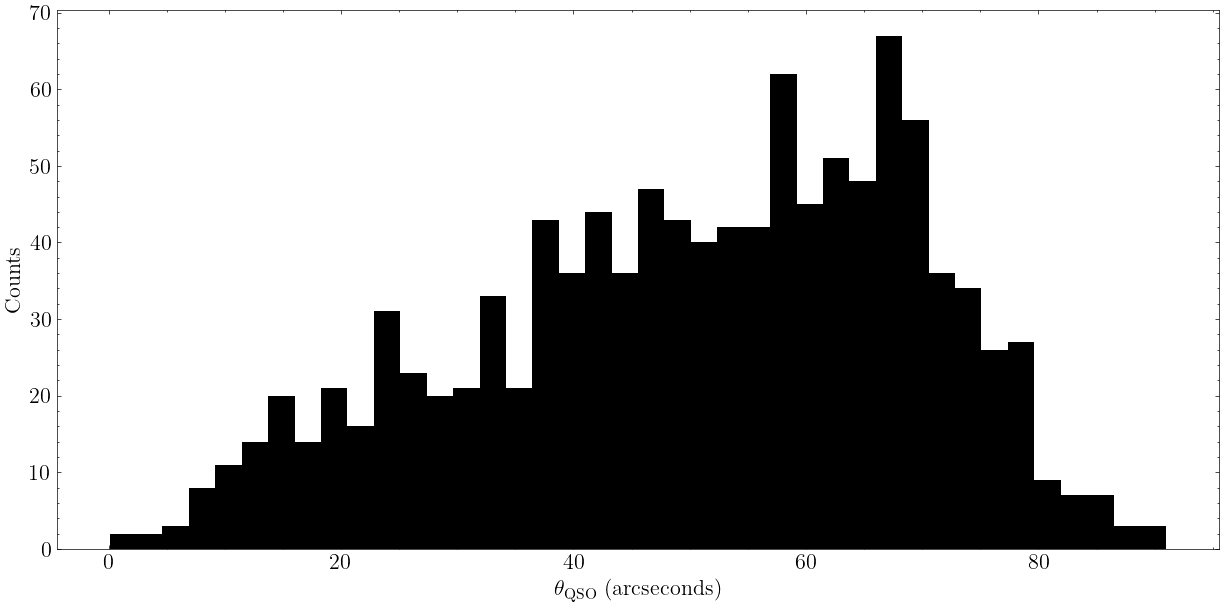

In [15]:
fig, ax = plt.subplots(1, figsize=(15,7))
ax.hist(df['theta'], bins=40)

ax.set_xlabel(r'$\theta_\mathrm{QSO}$ (arcseconds)')
ax.set_ylabel('Counts')

In [16]:
theta_partitions = [0,25,50,75,100]

In [17]:
df_sorted = pd.DataFrame(columns=df.columns)

In [18]:
for i in range(len(theta_partitions)-1):
    
    theta_min = theta_partitions[i]
    theta_max = theta_partitions[i+1]
    
    df_slice = df.loc[(df['theta']>=theta_min)&(df['theta']<=theta_max)].sort_values('f160w_mag')
        
    df_sorted = df_sorted.append(df_slice)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_13075/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.append(df_slice)
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_13075/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.append(df_slice)
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_13075/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sorted.append(df_slice)
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_13075/840781410.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sorted = df_sort

In [19]:
df_sorted

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
461,231.106859,9.977688,-1.00,23.04,27.99,-1.0,-1.0,-1.0,-1.0,19.677603,-1.0
359,231.102481,9.980198,-1.00,23.73,27.50,-1.0,-1.0,-1.0,-1.0,19.606745,-1.0
462,231.100021,9.975330,-1.00,23.60,-1.00,-1.0,-1.0,-1.0,-1.0,7.901759,-1.0
366,231.096478,9.978184,-1.00,24.14,28.04,-1.0,-1.0,-1.0,-1.0,23.655196,-1.0
736,231.103785,9.968458,-1.00,22.55,28.30,-1.0,-1.0,-1.0,-1.0,23.397418,-1.0
...,...,...,...,...,...,...,...,...,...,...,...
16,231.092749,9.955428,22.76,22.08,-1.00,-1.0,-1.0,-1.0,-1.0,77.202623,-1.0
68,231.080630,9.981743,22.91,21.59,25.08,-1.0,-1.0,-1.0,-1.0,80.412294,-1.0
5,231.091197,9.952817,23.04,21.23,-1.00,-1.0,-1.0,-1.0,-1.0,88.061051,-1.0
33,231.119600,9.961566,23.11,22.65,-1.00,-1.0,-1.0,-1.0,-1.0,77.938865,-1.0


In [20]:
df_sorted[df_sorted['z']==0.6780]

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
680,231.095997,9.967605,20.77,20.68,23.61,26.62,25.23,24.83,0.678,33.806604,241.936541


In [21]:
df_sorted[df_sorted['z']==0.7293]

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
496,231.108912,9.975914,20.21,20.28,22.25,24.16,23.3,22.79,0.7293,24.251508,178.436881


In [22]:
df_sorted[df_sorted['z']==1.0959]

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
280,231.099772,9.981098,22.82,22.55,25.53,27.27,27.02,26.37,1.0959,24.351755,202.365912


In [23]:
df_spec_z = df_sorted[(df_sorted['z']!=-1) & (df_sorted['z']!=0) & (df_sorted['z']<=1.3276)].sort_values('z')

In [24]:
len(df_spec_z)

34

In [25]:
df_spec_z

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj
264,231.101562,9.982189,20.95,21.09,23.76,25.21,24.75,24.70,0.0966,26.830391,49.974039
396,231.102948,9.976000,16.32,16.34,17.59,18.95,18.21,17.77,0.1203,5.242843,12.340876
395,231.103384,9.977022,17.31,17.40,18.97,20.07,19.52,19.21,0.1204,9.204546,21.664207
213,231.097411,9.982920,21.41,21.42,23.80,24.54,24.20,23.80,0.1393,33.881520,84.258593
529,231.096240,9.971248,21.30,21.16,25.72,26.85,26.49,26.23,0.2791,24.542556,105.133590
655,231.098210,9.969310,22.60,22.63,25.76,27.39,27.20,26.54,0.2915,24.132906,109.158564
555,231.101887,9.971807,20.29,20.27,23.13,24.56,23.94,23.59,0.3198,10.680617,50.176424
528,231.099128,9.971625,18.53,18.70,20.19,21.97,20.80,20.19,0.3286,15.620245,74.986737
700,231.105232,9.969616,21.56,21.57,24.85,25.62,24.93,24.73,0.3752,21.459975,113.177099
468,231.098332,9.974461,21.99,21.86,25.04,27.39,26.37,25.96,0.3759,13.661293,72.011215


In [26]:
z_list = [str(z) for z in df_spec_z['z']]
d_proj_list = [str(d) for d in df_spec_z['d_proj']]

In [27]:
CIV_EW_list = ['<44', '<50', '<49', '<49', '<105', 
               '<97',#'227, -32, +32', 
               '<157', '<123', '<93', 
               '<95', '<73', '<69', '<59', '<60', '<62', '<47', 
               '<48', 
               '<67', '<67','<67',#'254, -22, +22', '254, -22, +22', '254, -22, +22', 
               '<58','<46', '<52', '<52', 
               '157, -18, +18','<49', '<49', 
               '-10', '-10', '199, -3, +3', 
               '<12', '16, -3, +3', '176, -3, +3', '<8']

In [28]:
df_spec_z['CIV'] = CIV_EW_list

In [29]:
df_spec_z

,RA,Dec,f160w_mag,f140w_mag,f814w_mag,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z,theta,d_proj,CIV
264,231.101562,9.982189,20.95,21.09,23.76,25.21,24.75,24.70,0.0966,26.830391,49.974039,<44
396,231.102948,9.976000,16.32,16.34,17.59,18.95,18.21,17.77,0.1203,5.242843,12.340876,<50
395,231.103384,9.977022,17.31,17.40,18.97,20.07,19.52,19.21,0.1204,9.204546,21.664207,<49
213,231.097411,9.982920,21.41,21.42,23.80,24.54,24.20,23.80,0.1393,33.881520,84.258593,<49
529,231.096240,9.971248,21.30,21.16,25.72,26.85,26.49,26.23,0.2791,24.542556,105.133590,<105
655,231.098210,9.969310,22.60,22.63,25.76,27.39,27.20,26.54,0.2915,24.132906,109.158564,<97
555,231.101887,9.971807,20.29,20.27,23.13,24.56,23.94,23.59,0.3198,10.680617,50.176424,<157
528,231.099128,9.971625,18.53,18.70,20.19,21.97,20.80,20.19,0.3286,15.620245,74.986737,<123
700,231.105232,9.969616,21.56,21.57,24.85,25.62,24.93,24.73,0.3752,21.459975,113.177099,<93
468,231.098332,9.974461,21.99,21.86,25.04,27.39,26.37,25.96,0.3759,13.661293,72.011215,<95


# Plot $W_r$ versus $z$

In [30]:
def process_data_str(s, non_det_err):
    
    # Check if the point should be plotted or not
    bool_plot = False
    # Coordinate value
    coord_value = np.nan
    # Lower error
    err_lo = 0
    # Upper error
    err_hi = 0
    # Boolean for upper limit
    uplim = False
    # Boolean for lower limit
    lolim = False
    
    # If we don't have an empty string 
    if len(s)!=0:
        
        # Then it needs to be plotted
        bool_plot = True
        
        # Now, check for a non-detection first
        
        # Upper limit
        if s[0] == '<':
            # Set coordinate value
            coord_value = float(s[1:])
            # Only lower error
            uplim = True
            err_lo = non_det_err
            
        # Lower limit
        elif s[0] == '>':
            # Set coordinate value
            coord_value = float(s[1:])
            # Only upper error
            lolim = True
            err_hi = non_det_err
            
        # Detection
        else:
            s_arr = np.array(s.split(','), dtype=float)
            
            # Errors not provided
            if len(s_arr) == 1:
                coord_value = s_arr[0]
                err_lo = 0
                err_hi = 0
                
            # Errors provided
            else:
                coord_value = s_arr[0]
                err_lo = -s_arr[1] # Negative sign to flip the already present negative sign
                err_hi = s_arr[2]
        
    return bool_plot, coord_value, err_lo, err_hi, uplim, lolim

In [39]:
def plot_data_strings(ax, s_x, s_y, c, m, non_det_err_x=0.3, non_det_err_y=0.3, alpha=1):
    
    # First process each data string
    bool_plot_x, coord_value_x, err_lo_x, err_hi_x, uplim_x, lolim_x = process_data_str(s_x, non_det_err_x)
    bool_plot_y, coord_value_y, err_lo_y, err_hi_y, uplim_y, lolim_y = process_data_str(s_y, non_det_err_y)

    ax.errorbar(x=coord_value_x, y=coord_value_y,
                xerr=[[err_lo_x], [err_hi_x]],
                yerr=[[err_lo_y], [err_hi_y]], 
                color=c, alpha=alpha,
                marker=m, markersize=4.5, capsize=2, elinewidth=0.7,
                xuplims = uplim_x, xlolims= lolim_x,
                uplims = uplim_y, lolims= lolim_y) 

Compare column densities and linewidths for species

In [40]:
def compare_plot(ax, list_1, list_2, non_det_err_x, non_det_err_y, c):

    for i in range(len(list_1)):
        
        plot_data_strings(ax, list_1[i], list_2[i], 
                          c, 'o', 
                          non_det_err_x=non_det_err_x, non_det_err_y=non_det_err_y)

In [41]:
#z_list

In [42]:
z_non_det_list = []
d_proj_non_det_list = []
CIV_EW_non_det_list = []

z_det_list = []
d_proj_det_list = []
CIV_EW_det_list = []

for i in range(len(CIV_EW_list)):
    
    if CIV_EW_list[i][0] == '<':
        z_non_det_list.append(z_list[i])
        d_proj_non_det_list.append(d_proj_list[i])
        CIV_EW_non_det_list.append(CIV_EW_list[i])
        
    elif CIV_EW_list[i][0] == '-':
        pass
    
    else:
        z_det_list.append(z_list[i])
        d_proj_det_list.append(d_proj_list[i])
        CIV_EW_det_list.append(CIV_EW_list[i])

In [43]:
z_det_list

['0.678', '1.0959', '1.2256', '1.2787']

In [44]:
d_proj_det_list

['241.93654079897814',
 '202.36591172219954',
 '126.43095225674688',
 '178.8212824800992']

In [45]:
z_non_gal_list = ['1.0443', '1.1659', '1.2594']
CIV_EW_non_gal_list = ['342, -7, +7', '120, -4, +4', '13, -3, +3']

In [46]:
#z_group_list = ['0.6164', '0.6174', '0.6178']
#d_proj_group_list = ['398.253834', '117.581142', '163.708001']
#CIV_EW_group_list = ['254, -22, +22', '254, -22, +22', '254, -22, +22']

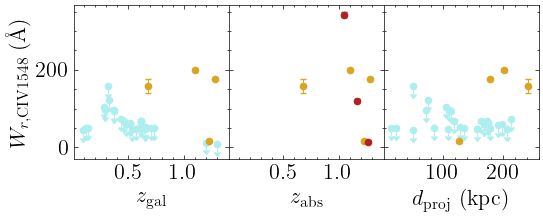

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(3*2,2), sharey=True)

compare_plot(axes[0], z_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[0], z_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')

axes[0].set_xlim(0.01,1.4)
axes[0].set_xlabel(r'$z_\mathrm{gal}$')
axes[0].set_ylabel(r'$W_{r, \mathrm{CIV 1548}} $ (Å)')

compare_plot(axes[1], z_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
compare_plot(axes[1], z_non_gal_list, CIV_EW_non_gal_list, 0.3, 20, 'firebrick')
axes[1].set_xlim(0.01,1.4)
axes[1].set_xlabel(r'$z_\mathrm{abs}$')

compare_plot(axes[2], d_proj_non_det_list, CIV_EW_non_det_list, 0.3, 20, 'paleturquoise')
compare_plot(axes[2], d_proj_det_list, CIV_EW_det_list, 0.3, 20, 'goldenrod')
axes[2].set_xlim(0.01,260)
axes[2].set_xlabel(r'$d_\mathrm{proj}$ (kpc)')

#ax.set_ylim(-6,269)

plt.subplots_adjust(wspace=0, hspace=0)

plt.savefig(rootdir+'CIV_sample.pdf', dpi=300)